# Finite Strain Contact

Compute the deformation of an elastic half-ring pushed against an elastic block. The results are then compared with those reported in [1, pp. 110-114].

## Reference

[1] Rabii Mlika, *Nitsche Method for Frictional Contact and Self-Contact: Mathematical and Numerical Study*, 2019.

In [42]:
import gmsh
import dolfinx.fem.petsc
from mpi4py import MPI
import viskex
import pyvista as pv
import ufl
import numpy as np
from petsc4py import PETSc
from pathlib import Path
import shutil
from matplotlib import pyplot as plt

rank = 0
comm = MPI.COMM_WORLD
pv.set_jupyter_backend("static")

# Results folder
results = Path("./results_contact_finite_strain")
if results.exists():
    shutil.rmtree(results)
results.mkdir()

# Mesh properties
pdim = 0
bdim = 1
gdim = 2

BODY_1 = 1
BODY_2 = 2
BODY_3 = 3

ARCH_CONTACT    = 4
BASE_BOTTOM     = 5
BASE_TOP        = 6

ARCH_ENDS   = 7
MIDDLE      = 8
DISP        = 9
SYM         = 10

element = ("Lagrange", 1, (gdim,))

# Contact properties
gauss_xi1   = 0.5 - 0.5 / np.sqrt(3.0)
gauss_xi2   = 0.5 + 0.5 / np.sqrt(3.0)
weight      = 0.5

penalty_eps = 7.5e3

N1 = lambda xi: (1 - xi)
N2 = lambda xi: xi

# Material properties
E1 = 1e3
E2 = 1e5
E3 = 3e2
nu = 0.3

# Iteration tolerances
max_iter    = 1000
steps       = 140
U_goal      = -70
tol         = 1e-6
alpha       = 0.8

Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Circle)
Info    : [ 10%] Meshing curve 2 (Circle)
Info    : [ 20%] Meshing curve 3 (Circle)
Info    : [ 30%] Meshing curve 4 (Line)
Info    : [ 40%] Meshing curve 5 (Line)
Info    : [ 50%] Meshing curve 6 (Line)
Info    : [ 60%] Meshing curve 7 (Line)
Info    : [ 70%] Meshing curve 8 (Line)
Info    : [ 80%] Meshing curve 9 (Line)
Info    : [ 90%] Meshing curve 10 (Line)
Info    : [100%] Meshing curve 11 (Line)
Info    : Done meshing 1D (Wall 0.00359867s, CPU 0.006511s)
Info    : Meshing 2D...
Info    : [  0%] Meshing surface 1 (Transfinite)
Info    : [ 40%] Meshing surface 2 (Transfinite)
Info    : [ 70%] Meshing surface 3 (Transfinite)
Info    : Done meshing 2D (Wall 0.00216661s, CPU 0.002576s)
Info    : 396 nodes 830 elements
Info    : Recombining 2D mesh...
Info    : Blossom: 63 internal 64 closed
Info    : Blossom recombination completed (Wall 0.000571431s, CPU 0.000615s): 32 quads, 0 triangles, 0 invalid quads, 0 quads with

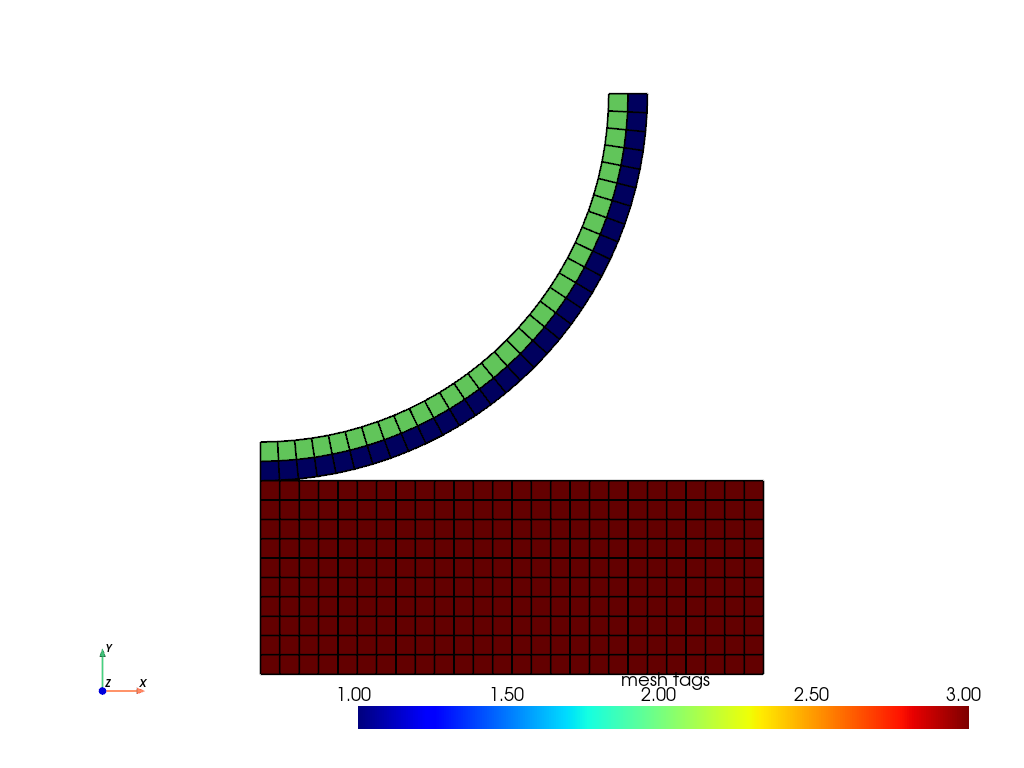

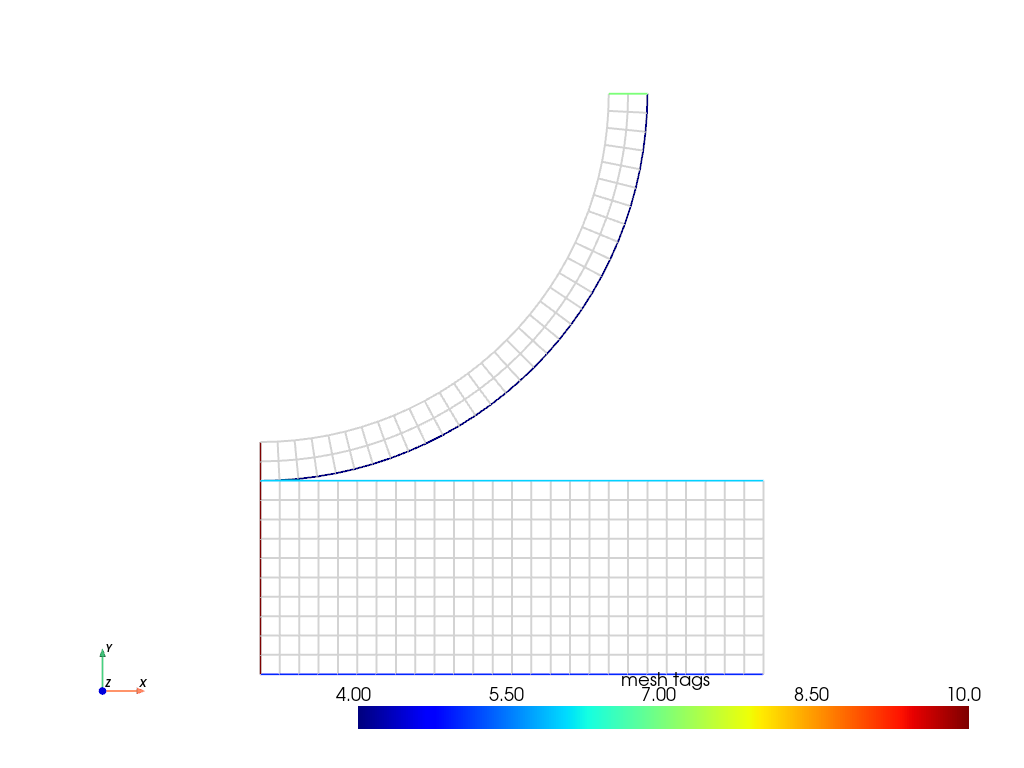

In [43]:
gmsh.initialize()
gmsh.model.add("finite-strain")

occ = gmsh.model.occ

# Lines and Surfaces
occ.add_circle(0, 0, 0, 100, angle1=3/2*np.pi, angle2=0)
occ.add_circle(0, 0, 0, 95, angle1=3/2*np.pi, angle2=0)
occ.add_circle(0, 0, 0, 90, angle1=3/2*np.pi, angle2=0)

occ.add_line(2, 4)
occ.add_line(4, 6)
occ.add_line(5, 3)
occ.add_line(3, 1)

occ.add_curve_loop([1, 4, -2, 7])
occ.add_curve_loop([2, 5, -3, 6])
occ.add_plane_surface([1])
occ.add_plane_surface([2])
occ.add_rectangle(0, -100-50, 0, 130, 50)

occ.synchronize()

# Physical tags
gmsh.model.add_physical_group(gdim, [1], BODY_1)
gmsh.model.add_physical_group(gdim, [2], BODY_2)
gmsh.model.add_physical_group(gdim, [3], BODY_3)

gmsh.model.add_physical_group(bdim, [1], ARCH_CONTACT)
gmsh.model.add_physical_group(bdim, [8], BASE_BOTTOM)
gmsh.model.add_physical_group(bdim, [10], BASE_TOP)

gmsh.model.add_physical_group(bdim, [4, 5], ARCH_ENDS)
gmsh.model.add_physical_group(pdim, [5], MIDDLE)
gmsh.model.add_physical_group(bdim, [6, 7, 11], SYM)

# Transfinite mesh
for curve_id in (4, 5, 6, 7):
    gmsh.model.mesh.set_transfinite_curve(curve_id, 2)

for curve_id in (1, 2, 3):
    gmsh.model.mesh.set_transfinite_curve(curve_id, 33)

for curve_id in (11, -9):
    gmsh.model.mesh.set_transfinite_curve(curve_id, 11)

for curve_id in (8, -10):
    gmsh.model.mesh.set_transfinite_curve(curve_id, 27)

gmsh.model.mesh.set_transfinite_surface(1)
gmsh.model.mesh.set_transfinite_surface(2)
gmsh.model.mesh.set_transfinite_surface(3)
gmsh.model.mesh.generate(gdim)
gmsh.model.mesh.recombine()
mesh_data = dolfinx.io.gmsh.model_to_mesh(gmsh.model, comm, rank, gdim)
gmsh.finalize()

domain          = mesh_data.mesh
facet_tags      = mesh_data.facet_tags
cell_tags       = mesh_data.cell_tags
ridge_tags      = mesh_data.ridge_tags

middle_idx      = ridge_tags.find(MIDDLE).item()
slave_facets    = facet_tags.find(ARCH_CONTACT)
master_facets   = facet_tags.find(BASE_TOP)

tdim            = domain.topology.dim
fdim            = tdim - 1
x_current       = domain.geometry.x[:, :tdim].copy()
facet_to_node   = domain.topology.connectivity(1, 0)
facet_to_cell   = domain.topology.connectivity(1, 2)
cell_to_node    = domain.topology.connectivity(2, 0)

viskex.dolfinx.plot_mesh_tags(domain, cell_tags)
viskex.dolfinx.plot_mesh_tags(domain, facet_tags)

In [44]:
def neo_hookean_energy(u, E, nu):
    C10 = E / (4.0 * (1.0 + nu))
    D1  = 6 * (1 - 2*nu) / E

    i2 = ufl.Identity(tdim)
    f2 = i2 + ufl.grad(u)
    f3 = ufl.as_tensor(
        (
            (f2[0, 0], f2[0, 1], 0.0),
            (f2[1, 0], f2[1, 1], 0.0),
            (0.0, 0.0, 1.0),
        )
    )
    j = ufl.det(f2)
    c3 = f3.T * f3
    i1 = ufl.tr(c3)

    i1_bar = j ** (-2.0 / 3.0) * i1
    return C10 * (i1_bar - 3.0) +  1/D1 * (j - 1.0) ** 2

def closest_segment(x1):

    best_segment  = None
    best_xi2      = None
    best_distance = np.inf

    for segment in master_facets:
        nodes = facet_to_node.links(segment)

        n1      = nodes[0]
        n2      = nodes[1]
        x_21    = x_current[n1]
        x_22    = x_current[n2]

        a2  = x_22 - x_21
        xi2 = np.dot(x1 - x_21, a2)  / np.dot(a2, a2)

        if xi2 < 0.0 or xi2 > 1.0:
            continue

        x2      = N1(xi2) * x_21 + N2(xi2) * x_22
        dist    = np.linalg.norm(x1 - x2)

        if dist < best_distance:
            best_distance   = dist
            best_segment    = segment
            best_xi2        = xi2

    found = best_segment is not None
    return found, best_segment, best_xi2

def segment_normal(segment, X11, X12):

    cell    = facet_to_cell.links(segment).item()
    nodes   = cell_to_node.links(cell)

    p1 = nodes[0]
    p2 = nodes[1]
    p3 = nodes[2]
    p4 = nodes[3]

    x_n1 = x_current[p1]
    x_n2 = x_current[p2]
    x_n3 = x_current[p3]
    x_n4 = x_current[p4]
    x_m  = (x_n1 + x_n2 + x_n3 + x_n4) / 4

    a = X12 - X11
    n = np.array([a[1], -a[0]], dtype=float)
    n /= np.linalg.norm(n)

    facet_mid = 0.5 * (X11 + X12)
    if np.dot(n, x_m - facet_mid) > 0.0:
        n *= -1.0

    return n

def contact_gauss(J, R, xi1):

    for segment in slave_facets:
        rows    = []

        # Slave
        nodes   = facet_to_node.links(segment)
        p1      = nodes[0]
        p2      = nodes[1]
        x_11    = x_current[p1]
        x_12    = x_current[p2]
        a1      = x_12 - x_11
        x1      = N1(xi1) * x_11 + N2(xi1) * x_12
        found, master_segment, xi2 = closest_segment(x1)

        dof1 = [p1 * 2, p1 * 2 + 1]
        dof2 = [p2 * 2, p2 * 2 + 1]
        rows.extend(dof1)
        rows.extend(dof2)

        if not found:
            continue

        # Master
        nodes   = facet_to_node.links(master_segment)
        p1      = nodes[0]
        p2      = nodes[1]
        x_21    = x_current[p1]
        x_22    = x_current[p2]
        x2      = N1(xi2) * x_21 + N2(xi2) * x_22
        n2      = segment_normal(master_segment, x_21, x_22)
        gN      = np.dot(x1 - x2, n2)

        dof1 = [p1 * 2, p1 * 2 + 1]
        dof2 = [p2 * 2, p2 * 2 + 1]
        rows.extend(dof1)
        rows.extend(dof2)

        if gN > 0:
            continue

        Hc = np.zeros((2, 8))
        Hc[0, 0] = N1(xi1)
        Hc[0, 2] = N2(xi1)
        Hc[0, 4] = -N1(xi2)
        Hc[0, 6] = -N2(xi2)

        Hc[1, 1] = N1(xi1)
        Hc[1, 3] = N2(xi1)
        Hc[1, 5] = -N1(xi2)
        Hc[1, 7] = -N2(xi2)

        Bc = n2.reshape(1, -1) @ Hc
        pN = penalty_eps * gN

        Fc = weight * pN * Bc.T * np.linalg.norm(a1)
        Kc = weight * penalty_eps * Bc.T @ Bc * np.linalg.norm(a1)

        R.setValues(rows, Fc, addv=PETSc.InsertMode.ADD_VALUES)
        J.setValues(rows, rows, Kc, addv=PETSc.InsertMode.ADD_VALUES)

def assemble_contact(J, R):

    contact_gauss(J, R, gauss_xi1)
    contact_gauss(J, R, gauss_xi2)

dx = ufl.Measure("dx", domain, subdomain_data=cell_tags)
ds = ufl.Measure("ds", domain, subdomain_data=facet_tags)

V = dolfinx.fem.functionspace(domain, element)

uh          = dolfinx.fem.Function(V, name="u")
du          = dolfinx.fem.Function(V)
v           = ufl.TestFunction(V)
du_trial    = ufl.TrialFunction(V)

# Dirichlet
U = dolfinx.fem.Constant(domain, [0.0, 0.0])

bc_symmetry = dolfinx.fem.dirichletbc(
    dolfinx.default_scalar_type(0.0),
    dolfinx.fem.locate_dofs_topological(V.sub(0), fdim, facet_tags.find(SYM)),
    V.sub(0),
)

bc_bottom = dolfinx.fem.dirichletbc(
    dolfinx.default_scalar_type([0.0, 0.0]),
    dolfinx.fem.locate_dofs_topological(V, fdim, facet_tags.find(BASE_BOTTOM)),
    V,
)

bc_ends = dolfinx.fem.dirichletbc(
    U,
    dolfinx.fem.locate_dofs_topological(V, fdim, facet_tags.find(ARCH_ENDS)),
    V,
)

bcs = [bc_symmetry, bc_bottom, bc_ends]

bc_dofs = []
for bc in bcs:
    bc.set(uh.x.array)
    indices, unrolled = bc.dof_indices()
    bc_dofs.extend(indices)
bc_dofs = np.unique(bc_dofs).astype(np.int32)

# Material
Psi1 = neo_hookean_energy(uh, E1, nu)
Psi2 = neo_hookean_energy(uh, E2, nu)
Psi3 = neo_hookean_energy(uh, E3, nu)
Psi_total = Psi1 * dx(BODY_1) + Psi2 * dx(BODY_2) + Psi3 * dx(BODY_3)

residual    = ufl.derivative(Psi_total, uh, v)
jacobian    = ufl.derivative(residual, uh, du_trial)
R_form      = dolfinx.fem.form(residual)
J_form      = dolfinx.fem.form(jacobian)

R = dolfinx.fem.petsc.create_vector(dolfinx.fem.extract_function_spaces(R_form))
J = dolfinx.fem.petsc.create_matrix(J_form)

# Solver
solver = PETSc.KSP().create(domain.comm)
solver.setOperators(J)
solver.setType("preonly")
solver.getPC().setType("lu")

out_file = dolfinx.io.XDMFFile(comm, results / "disp.xdmf", "w")
out_file.write_mesh(domain)

# Iteration
u_imposed = np.linspace(0, U_goal, steps)
u_fenicsx = u_imposed.copy()
for i in range(steps):
    u_current  = u_imposed[i]
    U.value[1] = u_current

    for bc in bcs:
        bc.set(uh.x.array)

    for j in range(max_iter):

        with R.localForm() as loc_R:
            loc_R.set(0)
        J.zeroEntries()

        dolfinx.fem.petsc.assemble_matrix(J, J_form)
        dolfinx.fem.petsc.assemble_vector(R, R_form)
        J.setOption(PETSc.Mat.Option.NEW_NONZERO_ALLOCATION_ERR, False)

        x_current[:, :] = domain.geometry.x[:, :tdim] + uh.x.array.reshape((-1, 2))

        assemble_contact(J, R)

        J.assemble()
        R.assemble()

        J.zeroRowsColumns(bc_dofs, diag=1.0)

        rhs = R.copy()
        rhs.scale(-1.0)
        rhs.setValues(bc_dofs, np.zeros(bc_dofs.shape), addv=PETSc.InsertMode.INSERT_VALUES)
        rhs.assemble()

        du.x.array[:] = 0.0
        solver.setOperators(J)
        solver.solve(rhs, du.x.petsc_vec)

        residual = np.linalg.norm(du.x.array)
        uh.x.array[:] += alpha * du.x.array

        print(f"Step {i+1:3d}, u = {u_current:.3e}, Iteration {j+1:3d}, norm(du) = {residual:.2e}")

        if residual < tol:
            break

    else:
        raise RuntimeError(
            f"Couldn't converge in step {i + 1}: "
            f"norm(du) = {residual:.3e}"
        )

    u_fenicsx[i] = uh.x.array.reshape(-1, 2)[middle_idx, 1]
    out_file.write_function(uh, i)

out_file.close()

Step   1, u = 0.000e+00, Iteration   1, norm(du) = 1.05e-13
Step   2, u = -5.036e-01, Iteration   1, norm(du) = 4.46e+00
Step   2, u = -5.036e-01, Iteration   2, norm(du) = 1.33e+00
Step   2, u = -5.036e-01, Iteration   3, norm(du) = 2.91e-01
Step   2, u = -5.036e-01, Iteration   4, norm(du) = 4.07e-01
Step   2, u = -5.036e-01, Iteration   5, norm(du) = 8.16e-02
Step   2, u = -5.036e-01, Iteration   6, norm(du) = 1.63e-02
Step   2, u = -5.036e-01, Iteration   7, norm(du) = 3.26e-03
Step   2, u = -5.036e-01, Iteration   8, norm(du) = 6.51e-04
Step   2, u = -5.036e-01, Iteration   9, norm(du) = 1.30e-04
Step   2, u = -5.036e-01, Iteration  10, norm(du) = 2.60e-05
Step   2, u = -5.036e-01, Iteration  11, norm(du) = 5.19e-06
Step   2, u = -5.036e-01, Iteration  12, norm(du) = 1.04e-06
Step   2, u = -5.036e-01, Iteration  13, norm(du) = 2.07e-07
Step   3, u = -1.007e+00, Iteration   1, norm(du) = 4.21e+00
Step   3, u = -1.007e+00, Iteration   2, norm(du) = 1.23e+00
Step   3, u = -1.007e+00,

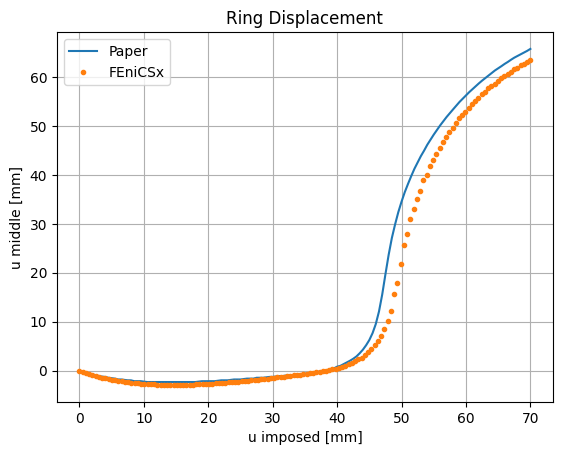

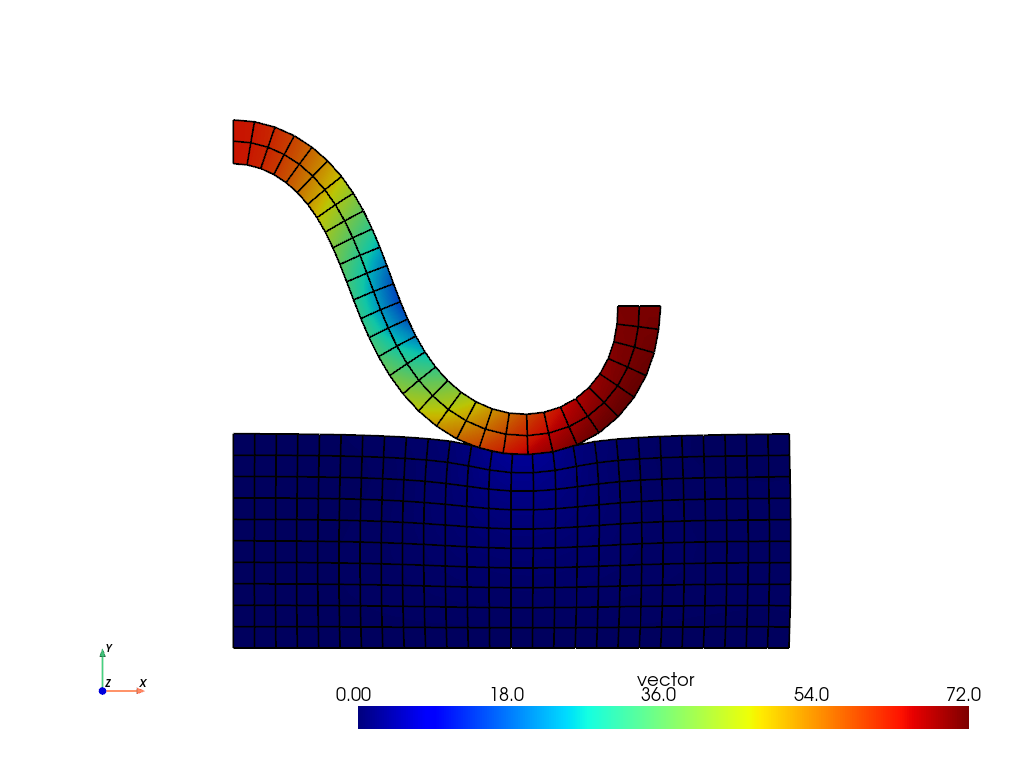

In [ ]:
ref_data = np.array([
    [0.0, 0.000],
    [0.5, -0.291],
    [1.0, -0.438],
    [1.5, -0.613],
    [2.0, -0.787],
    [2.5, -0.961],
    [3.0, -1.135],
    [3.5, -1.244],
    [4.0, -1.309],
    [4.5, -1.483],
    [5.0, -1.571],
    [5.5, -1.658],
    [6.0, -1.832],
    [6.5, -1.832],
    [7.0, -1.919],
    [7.5, -2.006],
    [8.0, -2.006],
    [8.5, -2.180],
    [9.0, -2.180],
    [9.5, -2.180],
    [10.0, -2.265],
    [10.5, -2.354],
    [11.0, -2.354],
    [11.5, -2.354],
    [12.0, -2.354],
    [12.5, -2.354],
    [13.0, -2.354],
    [13.5, -2.354],
    [14.0, -2.354],
    [14.5, -2.354],
    [15.0, -2.354],
    [15.5, -2.354],
    [16.0, -2.354],
    [16.5, -2.354],
    [17.0, -2.354],
    [17.5, -2.354],
    [18.0, -2.354],
    [18.5, -2.267],
    [19.0, -2.188],
    [19.5, -2.180],
    [20.0, -2.180],
    [20.5, -2.180],
    [21.0, -2.180],
    [21.5, -2.093],
    [22.0, -2.006],
    [22.5, -2.006],
    [23.0, -2.006],
    [23.5, -1.919],
    [24.0, -1.832],
    [24.5, -1.832],
    [25.0, -1.832],
    [25.5, -1.745],
    [26.0, -1.658],
    [26.5, -1.658],
    [27.0, -1.658],
    [27.5, -1.483],
    [28.0, -1.483],
    [28.5, -1.483],
    [29.0, -1.396],
    [29.5, -1.309],
    [30.0, -1.309],
    [30.5, -1.222],
    [31.0, -1.135],
    [31.5, -1.135],
    [32.0, -1.048],
    [32.5, -0.961],
    [33.0, -0.961],
    [33.5, -0.874],
    [34.0, -0.787],
    [34.5, -0.787],
    [35.0, -0.613],
    [35.5, -0.613],
    [36.0, -0.449],
    [36.5, -0.438],
    [37.0, -0.264],
    [37.5, -0.160],
    [38.0, -0.090],
    [38.5, 0.084],
    [39.0, 0.258],
    [39.5, 0.432],
    [40.0, 0.781],
    [40.5, 0.955],
    [41.0, 1.303],
    [41.5, 1.628],
    [42.0, 2.000],
    [42.5, 2.401],
    [43.0, 2.879],
    [43.5, 3.523],
    [44.0, 4.258],
    [44.5, 5.167],
    [45.0, 6.234],
    [45.5, 7.638],
    [46.0, 9.495],
    [46.5, 12.071],
    [47.0, 15.535],
    [47.5, 19.683],
    [48.0, 23.658],
    [48.5, 27.119],
    [49.0, 29.894],
    [49.5, 32.399],
    [50.0, 34.537],
    [50.5, 36.480],
    [51.0, 38.155],
    [51.5, 39.758],
    [52.0, 41.269],
    [52.5, 42.565],
    [53.0, 43.860],
    [53.5, 44.982],
    [54.0, 46.191],
    [54.5, 47.226],
    [55.0, 48.260],
    [55.5, 49.208],
    [56.0, 50.155],
    [56.5, 51.021],
    [57.0, 51.876],
    [57.5, 52.665],
    [58.0, 53.423],
    [58.5, 54.196],
    [59.0, 54.945],
    [59.5, 55.605],
    [60.0, 56.253],
    [60.5, 56.941],
    [61.0, 57.549],
    [61.5, 58.140],
    [62.0, 58.739],
    [62.5, 59.299],
    [63.0, 59.821],
    [63.5, 60.343],
    [64.0, 60.866],
    [64.5, 61.386],
    [65.0, 61.811],
    [65.5, 62.259],
    [66.0, 62.722],
    [66.5, 63.130],
    [67.0, 63.582],
    [67.5, 64.001],
    [68.0, 64.349],
    [68.5, 64.698],
    [69.0, 65.046],
    [69.5, 65.394],
    [70.0, 65.794]
])

u_imposed2  = ref_data[:, 0]
u_ref       = ref_data[:, 1]

plt.plot(u_imposed2, u_ref)
plt.plot(-u_imposed, u_fenicsx, ".")
plt.legend(["Paper", "FEniCSx"])
plt.xlabel("u imposed [mm]")
plt.ylabel("u middle [mm]")
plt.title("Middle Displacement")
plt.grid(True)
plt.show()

viskex.dolfinx.plot_vector_field(uh, warp_factor=1)